<a href="https://colab.research.google.com/github/Rus18mc/nash/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22NASH%2BML%2BHIPPOS%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NASH — Russia-Adjusted Geopolitical Risk: Full Pipeline

Notebook to the coursework **"The Impact of Geopolitics on the
Stock Prices of Metallurgical and Oil Companies in Russia."**

This notebook builds the NASH index with the help of two raw
Russian-language news datasets used in the thesis, then merges them with
stock prices and the global macro/GPR panel and runs all statistical
tests and ML comparisons.

### NASH — three design features
1. **False-positive filter** — STRONG / WEAK dictionary split with a
   metaphor black-list (`ценовая война`, `паническая атака`,
   `холодная война`, …). A WEAK-only article is classified as tension
   only if it contains ≥ 2 distinct weak tokens **or** ≥ 1 weak token
   together with a political actor (`Россия`, `США`, `ЕС`, `Китай`, `Иран`, …).
2. **Sentiment decomposition** — a parallel RELIEF lexicon (`перемирие`,
   `урегулирование`, `снят санкций`, `прекращение огня`, `деэскалация`, …).
   Three daily series are produced:
   `NASH_tension`, `NASH_relief`, `NASH_net = tension − relief`.
3. **Multi-source corpus** — **Lenta.ru** (`unlabeled_news.csv`) +
   **RBC 2000–2020** (`rbc_2000_2020_clean.csv`). Per-date hits are
   summed across the two datasets.

In [67]:
import os, re, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import plotly.express as px

from scipy.stats import zscore
from scipy import stats
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})


In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
DATA_DIR   = '/content/drive/MyDrive/nash'
LENTA_PATH = os.path.join(DATA_DIR, 'unlabeled_news.csv')
RBC_PATH   = os.path.join(DATA_DIR, 'rbc_2000_2020_clean.csv')
MACRO_PATH = os.path.join(DATA_DIR, 'stock_data.csv')
D1_DIR     = os.path.join(DATA_DIR, 'D1.csv')

DATE_MIN = pd.Timestamp('2010-01-01')
DATE_MAX = pd.Timestamp('2020-12-31')

OIL_GAS = ['GAZP', 'LKOH', 'TATN', 'ROSN']
METALS  = ['CHMF', 'GMKN', 'NLMK', 'SNGS']
TICKERS = OIL_GAS + METALS


## 1. Dictionaries and scoring function

We translate the Caldara-Iacoviello (2022) approach to Russian and
add the three design features listed in the header (STRONG / WEAK
split, metaphor black-list, RELIEF lexicon).

In [70]:

STRONG = [
    # Санкции/эмбарго
    r'санкци', r'эмбарго', r'рестрикц', r'вторичн\s+санкц', r'экспортн\s+контрол',
    r'персональн\s+санкц', r'секторальн\s+санкц', r'замороз\w*\s+активов', r'конфиск\w*\s+активов',
    r'swift\s+отключ', r'потолок\s+цен', r'price\s+cap',

    # Тяжёлое оружие/ОМП
    r'ядерн\s+оруж', r'атомн\s+бомб', r'ядерн\s+удар', r'ядерн\s+угроз',
    r'тактическ\s+ядерн', r'стратегическ\s+ядерн', r'химическ\s+оруж', r'биологическ\s+оруж',
    r'оруж\s+массового', r'грязн\s+бомб', r'ому\b', r'омп\b', r'мбр\b',
    r'баллистическ\s+ракет', r'гиперзвуков', r'калибр', r'искандер', r'кинжал',
    r'циркон', r'шахед', r'герань-2', r'haimars', r'хаймарс', r'atacms', r'storm\s+shadow',
    r'таурус', r'абрамс', r'леопард', r'patriot',

    # Теракт/боестолкновения гос. уровня
    r'теракт', r'террористическ\s+акт', r'террористическ\s+атак', r'смертник',
    r'камикадзе', r'подрыв', r'взрыв\s+в\s+метро', r'взрыв\s+на\s+вокзал', r'захват\s+заложник', r'заминирован',

    # Геополитическая/военная рамка
    r'спецоперац', r'сво\b', r'военн\s+операц', r'военн\s+положени', r'чрезвычайн\s+положени',
    r'мобилизац', r'частичн\s+мобилизац', r'всеобщ\s+мобилизац', r'повестк\s+в\s+военкомат',
    r'военкомат', r'аннекси', r'оккупац', r'интервенц', r'вторжен', r'агресс',
    r'госпереворот', r'военн\s+переворот', r'путч', r'цветн\s+революц', r'майдан',

    # Спорные территории/точки конфликта
    r'крым', r'севастопол', r'донбасс', r'днр\b', r'лнр\b', r'доннр\b',
    r'донецк\s+народн', r'луганск\s+народн', r'херсон', r'запорожск\s+атомн',
    r'мариупол', r'авдеевк', r'бахмут', r'артёмовск', r'покровск', r'купянск',
    r'харьковск\s+направлен', r'курск\s+направлен', r'белгородск\s+направлен',
    r'приграничн', r'линия\s+соприкосновен', r'лбс\b', r'нагорн\s+карабах',
    r'карабахск', r'абхаз', r'южн\s+осети', r'приднестров', r'сектор\s+газа',
    r'западн\s+берег', r'голанск\s+высоты', r'тайваньск\s+пролив',
    r'южно-китайск\s+мор', r'кашмир', r'курильск\s+спор',

    # Военно-политические блоки/договоры под угрозой
    r'нато\b', r'восточн\s+фланг\s+нато', r'одкб\b', r'дрсмд\b', r'снв-3\b',
    r'довсе\b', r'двзия\b', r'ракетн\s+договор', r'новый\s+старт',

    # Радиация/ядерн. инфраструктура
    r'заэс\b', r'запорожск\s+аэс', r'чернобыль', r'ядерн\s+инцидент',
    r'ядерн\s+авари', r'радиационн\s+утечк',

    # Политические преследования/госбезопасность
    r'арест\s+по\s+делу\s+о\s+госизмен', r'госизмен', r'шпионаж',
    r'иноагент', r'экстремистск\s+организац', r'террористическ\s+организац',
]


WEAK = [
    # Боевые действия
    r'войн', r'военн', r'войск', r'войско', r'атак', r'удар', r'обстрел',
    r'бой', r'сражен', r'битв', r'наступлен', r'контрнаступлен', r'оборон',
    r'штурм', r'фронт', r'передов', r'перестрелк', r'стрельб', r'огонь\s+по',
    r'огневой', r'арт\.удар', r'артиллер', r'миномётн', r'танков', r'дрон',
    r'бпла\b', r'беспилотн', r'ракетн', r'бомбард',

    # Кризисы/напряжённость
    r'кризис', r'напряжен', r'эскалац', r'конфликт', r'противостоян',
    r'конфронтац', r'разногласи', r'раскол', r'раздор',

    # Угрозы/давление
    r'угроз', r'угрожа', r'давлен', r'ультиматум', r'шантаж', r'провокац',
    r'диверс', r'подрывн', r'саботаж', r'кибератак',

    # Насилие/жертвы
    r'жертв', r'погибш', r'убит', r'ранен', r'потер', r'тяжёл\s+ранен',
    r'массов\s+гибел', r'захват', r'блокад', r'осад', r'окружен', r'разгром', r'отступлен',

    # Беспорядки
    r'протест', r'митинг', r'демонстрац', r'беспоряд', r'мятеж', r'восстан',
    r'забастовк', r'погром', r'бунт', r'революц',

    # Сила/вооружён. контакт
    r'вооружён', r'вооружи', r'столкновен', r'инцидент', r'перехват', r'сбил',
]

METAPHOR_BLACKLIST = [
    # Экономические/рыночные «войны»
    r'ценов\s+войн', r'торгов\s+войн', r'валютн\s+войн', r'тарифн\s+войн',
    r'нефтян\s+войн', r'газов\s+войн', r'экономическ\s+войн', r'бюджетн\s+войн',
    r'налогов\s+войн', r'банковск\s+войн', r'рекламн\s+войн', r'брендов\s+войн',
    r'патентн\s+войн', r'пиар\s+войн', r'имиджев\s+войн', r'плакатн\s+войн',
    r'слов\s+войн', r'инфо\s+войн', r'культурн\s+войн', r'гендерн\s+войн',
    r'генетическ\s+войн', r'шахматн\s+войн', r'звёздн\s+войн', r'звездн\s+войн',

    # «Атаки» не-военные
    r'паническ\s+атак', r'сердечн\s+атак', r'астматическ\s+атак', r'эпилептическ\s+атак',
    r'мигренозн\s+атак', r'аллергическ\s+атак', r'психическ\s+атак', r'невротическ\s+атак',
    r'тревожн\s+атак', r'вирусн\s+атак', r'хакерск\s+атак', r'фишингов\s+атак',
    r'спам-атак', r'рекламн\s+атак', r'медиа\s+атак', r'словесн\s+атак',
    r'эмоциональн\s+атак', r'газов\s+атак', r'футбольн\s+атак', r'хоккейн\s+атак',

    # «Удары»
    r'удар\s+молни', r'удар\s+судьб', r'солнечн\s+удар', r'теплов\s+удар',
    r'электрическ\s+удар', r'удар\s+током', r'сердечн\s+удар', r'апоплексическ\s+удар',
    r'инсульт', r'инфаркт', r'ценов\s+удар', r'курсов\s+удар', r'рыночн\s+удар',
    r'валютн\s+удар', r'боксёрск\s+удар', r'каратист\s+удар', r'эмоциональн\s+удар',
    r'моральн\s+удар', r'репутационн\s+удар', r'удар\s+по\s+имидж', r'имиджев\s+удар',
    r'биржев\s+удар', r'налогов\s+удар', r'удар\s+в\s+футбол', r'штрафн\s+удар',
    r'углов\s+удар', r'пенальти\s+удар',

    # «Кризис» не-геополитический
    r'финансов\s+кризис', r'долгов\s+кризис', r'банковск\s+кризис', r'ипотечн\s+кризис',
    r'климатическ\s+кризис', r'экологическ\s+кризис', r'демографическ\s+кризис',
    r'кадров\s+кризис', r'мусорн\s+кризис', r'правительствен\s+кризис',
    r'парламентск\s+кризис', r'правов\s+кризис', r'моральн\s+кризис', r'духовн\s+кризис',
    r'идентичност\s+кризис', r'личност\s+кризис', r'семейн\s+кризис', r'творческ\s+кризис',
    r'кризис\s+жанра',

    # «Конфликт» — быт/корпорат.
    r'конфликт\s+интересов', r'семейн\s+конфликт', r'рабочий\s+конфликт',
    r'трудов\s+конфликт', r'корпоративн\s+конфликт', r'юридическ\s+конфликт',
    r'творческ\s+конфликт', r'конфликт\s+поколений',

    # «Бой» — спорт/быт
    r'хоккейн\s+бой', r'футбольн\s+бой', r'баскетбольн\s+бой', r'боксёрск\s+бой',
    r'мма\s+бой', r'товарищеск\s+бой', r'уличн\s+бой', r'рыцарск\s+бой',
    r'морск\s+бой', r'словесн\s+бой',

    # Цитирование
    r'война\s+и\s+мир', r'холодн\s+войн', r'мировой\s+войн\s+3',
]


ACTORS = [
    # Страны/государства (основные)
    r'росси', r'российск', r'рф\b', r'москв', r'кремл', r'ссср\b',
    r'сша\b', r'америк', r'соединённ\s+штат', r'соединен\s+штат', r'вашингтон',
    r'ес\b', r'европейск\s+союз', r'брюссель', r'нато\b',
    r'великобритан', r'британ', r'лондон', r'франци', r'французск', r'париж',
    r'германи', r'германск', r'берлин', r'польш', r'польск',
    r'украин', r'украинск', r'киев', r'беларус', r'белорусск', r'минск',
    r'китай', r'кнр\b', r'пекин', r'япон', r'токио', r'иран', r'тегеран',
    r'израиль', r'израильск', r'иерусалим', r'тель-авив', r'палестин',

    # Международные организации
    r'одкб\b', r'шос\b', r'брикс\b', r'g7\b', r'g20\b', r'опек\b', r'опек\+',
    r'еаэс\b', r'оон\b', r'обсе\b', r'мвф\b', r'вто\b',

    # Политические лидеры/институты
    r'путин', r'байден', r'трамп', r'зеленск', r'лукашенк', r'эрдоган',
    r'макрон', r'шольц', r'меркел', r'си\s+цзиньпин',
    r'пентагон', r'госдеп', r'белый\s+дом', r'конгресс\s+сша', r'фсб\b',
    r'свр\b', r'гру\b', r'минобороны', r'мид\b',
]


RELIEF = [
    # Прекращение боевых действий
    r'перемири', r'прекращен\w*\s+огн', r'режим\s+тишин', r'режим\s+прекращен\w*\s+огн',
    r'приостановк\s+боев', r'заморозк\s+конфликт', r'пауз\s+в\s+бо', r'гуманитарн\s+пауз',

    # Мирный процесс
    r'мирн\s+перегов', r'мирн\s+соглашен', r'мирн\s+план', r'мирн\s+инициатив',
    r'дорожн\s+карт', r'женевск\s+перегов', r'минск\s+соглашен', r'стамбульск\s+перегов',
    r'астанинск\s+формат', r'нормандск\s+формат', r'переговорн\s+процесс',
    r'возобновлен\w*\s+перегов', r'диалог\s+возобнов',

    # Урегулирование/нормализация
    r'урегулирован', r'мирн\s+урегулирован', r'политическ\s+урегулирован',
    r'дипломатическ\s+урегулирован', r'нормализац\s+отношен', r'нормализ',
    r'восстановлен\w*\s+отношен', r'разрядк', r'разрядка\s+напряжённ',
    r'разморозк\s+отношен', r'потеплен\w*\s+отношен',

    # Санкции — смягчение
    r'снят\w*\s+санкц', r'отмен\w*\s+санкц', r'ослаблен\w*\s+санкц',
    r'смягчен\w*\s+санкц', r'исключ\w*\s+из\s+санкционн\s+списк',
    r'разморозк\s+активов', r'возврат\s+активов', r'разблокир',
    r'отмен\w*\s+эмбарго', r'снят\w*\s+эмбарго',

    # Заложники/пленные
    r'освобожден\w*\s+заложник', r'освобожден\w*\s+пленн', r'обмен\s+пленн',
    r'обмен\s+заключённ', r'возврат\s+военнопленн', r'гуманитарн\s+обмен',

    # Разоружение/контроль вооружений
    r'разоружен', r'ядерн\s+разоружен', r'ограничен\w*\s+вооруж', r'сокращен\w*\s+вооруж',
    r'договор\s+снв', r'новый\s+старт', r'снв-3\s+продлен', r'контроль\s+вооруж',
    r'верификационн\s+визит', r'инспекц\s+магатэ',

    # Военное снижение присутствия
    r'вывод\s+войск', r'отвод\s+войск', r'отвод\s+сил', r'отступлен\w*\s+войск',
    r'демилитаризац', r'демобилизац', r'сокращен\w*\s+континген', r'закрыт\w*\s+военн\s+баз',

    # Гуманитарные каналы
    r'гуманитарн\s+помощ', r'гуманитарн\s+коридор', r'эвакуац\s+мирн',
    r'открыт\s+коридор', r'зерновая\s+сделк', r'черноморск\s+инициатив',

    # Дипломатический тон
    r'конструктивн\s+диалог', r'позитивн\s+сигнал', r'рукопожат',
    r'саммит\s+состоял', r'встреч\w*\s+на\s+высш\s+уровн', r'дипломатическ\s+усили',
    r'компромисс\s+достиг', r'договорённост\w*\s+достигн', r'соглашени\s+достиг',
    r'подписал\s+соглашен', r'ратифицировал', r'примирил',

    # Стабилизация
    r'стабилизац\s+ситуац', r'стабилизировал', r'снижен\w*\s+напряженн',
    r'деэскалац', r'деэскалировал', r'снизил\s+эскалац', r'обстановк\s+нормализ',

    # Отказ от эскалации
    r'отказ\s+от\s+эскалац', r'отказались\s+нанос\w*\s+удар', r'отозвал\s+угроз',
    r'снял\s+угроз', r'отменил\s+ядерн\s+учен',
]
PAT_STRONG = re.compile('|'.join(STRONG),  re.IGNORECASE)
PAT_WEAK   = re.compile('|'.join(WEAK),    re.IGNORECASE)
PAT_BLACK  = re.compile('|'.join(METAPHOR_BLACKLIST), re.IGNORECASE)
PAT_ACTORS = re.compile('|'.join(ACTORS),  re.IGNORECASE)
PAT_RELIEF = re.compile('|'.join(RELIEF),  re.IGNORECASE)


def score_text(text):
    """Return (tension_flag, relief_flag) booleans for one article."""
    if not isinstance(text, str):
        return 0, 0
    t = text.lower()
    strong = bool(PAT_STRONG.search(t))
    if strong:
        tension = 1
    else:
        cleaned = PAT_BLACK.sub(' ', t)
        weak_tokens = set(m.group(0) for m in PAT_WEAK.finditer(cleaned))
        actor_hit   = bool(PAT_ACTORS.search(cleaned))
        tension = int((len(weak_tokens) >= 2) or
                      (len(weak_tokens) >= 1 and actor_hit))
    relief = int(tension == 1 and bool(PAT_RELIEF.search(t)))
    return tension, relief


## 2. Streaming aggregator

Both corpora are large, so we score and aggregate in chunks of
1 000 rows at a time and keep only per-date counts in RAM.
The date filter `[DATE_MIN, DATE_MAX]` is applied before scoring.

In [71]:
def _aggregate_chunk(dates, body, source):
    scores = body.map(score_text)
    tension = np.fromiter((s[0] for s in scores), dtype=np.int8, count=len(scores))
    relief  = np.fromiter((s[1] for s in scores), dtype=np.int8, count=len(scores))
    mini = pd.DataFrame({'date': dates.values,
                         'tension': tension, 'relief': relief}).dropna(subset=['date'])
    if len(mini) == 0:
        return pd.DataFrame(columns=['date','source','news_volume',
                                     'tension_hits','relief_hits'])
    agg = (mini.groupby('date')
                .agg(news_volume=('tension','size'),
                     tension_hits=('tension','sum'),
                     relief_hits=('relief','sum'))
                .reset_index())
    agg['source'] = source
    return agg[['date','source','news_volume','tension_hits','relief_hits']]


def _accumulate(acc, agg):
    for d, v, t, r in zip(agg['date'].values,
                          agg['news_volume'].values,
                          agg['tension_hits'].values,
                          agg['relief_hits'].values):
        row = acc.get(d)
        if row is None:
            acc[d] = [int(v), int(t), int(r)]
        else:
            row[0] += int(v); row[1] += int(t); row[2] += int(r)


def _acc_to_frame(acc, source):
    if not acc:
        return pd.DataFrame(columns=['date','source','news_volume',
                                     'tension_hits','relief_hits'])
    out = pd.DataFrame({
        'date': list(acc.keys()),
        'source': source,
        'news_volume':  [v[0] for v in acc.values()],
        'tension_hits': [v[1] for v in acc.values()],
        'relief_hits':  [v[2] for v in acc.values()],
    })
    return out.sort_values('date').reset_index(drop=True)


def stream_lenta(path, chunksize=1_000):
    acc, total = {}, 0
    for ch in pd.read_csv(path, usecols=['date','title','text'],
                           chunksize=chunksize, on_bad_lines='skip'):
        d = pd.to_datetime(ch['date'], errors='coerce').dt.normalize()
        mask = (d >= DATE_MIN) & (d <= DATE_MAX)
        if not mask.any():
            total += len(ch); del ch; gc.collect(); continue
        ch = ch.loc[mask.values]; d = d.loc[mask.values]
        body = (ch['title'].fillna('') + ' ' + ch['text'].fillna('')).astype(str)
        _accumulate(acc, _aggregate_chunk(d, body, 'lenta'))
        total += len(ch)
        if total % 20_000 < chunksize:
            print(f'  Lenta processed ~{total:,}  | unique days so far: {len(acc):,}')
        del ch, d, body; gc.collect()
    return _acc_to_frame(acc, 'lenta')


def stream_rbc(path, chunksize=1_000):
    acc, total = {}, 0
    for ch in pd.read_csv(path, usecols=['publish_date','title','overview','text'],
                           chunksize=chunksize, on_bad_lines='skip'):
        d = pd.to_datetime(ch['publish_date'], errors='coerce', utc=True)
        d = d.dt.tz_localize(None).dt.normalize()
        mask = (d >= DATE_MIN) & (d <= DATE_MAX)
        if not mask.any():
            total += len(ch); del ch; gc.collect(); continue
        ch = ch.loc[mask.values]; d = d.loc[mask.values]
        body = (ch['title'].fillna('') + ' ' +
                ch['overview'].fillna('') + ' ' +
                ch['text'].fillna('')).astype(str)
        _accumulate(acc, _aggregate_chunk(d, body, 'rbc'))
        total += len(ch)
        if total % 10_000 < chunksize:
            print(f'  RBC   processed ~{total:,}  | unique days so far: {len(acc):,}')
        del ch, d, body; gc.collect()
    return _acc_to_frame(acc, 'rbc')


### Run the scorer on both datasets



In [72]:
print('Aggregating Lenta ...')
lenta_daily = stream_lenta(LENTA_PATH)
print('  Lenta daily rows:', len(lenta_daily))

print('Aggregating RBC   ...')
rbc_daily = stream_rbc(RBC_PATH)
print('  RBC   daily rows:', len(rbc_daily))

Aggregating Lenta ...
  Lenta processed ~20,000  | unique days so far: 1,070
  Lenta processed ~40,000  | unique days so far: 2,653
  Lenta daily rows: 3724
Aggregating RBC   ...
  RBC   processed ~10,184  | unique days so far: 1,203
  RBC   daily rows: 2964


### Combine sources and build the daily NASH series

In [73]:
src_daily = pd.concat([lenta_daily, rbc_daily], ignore_index=True)

scored_daily = (src_daily.groupby('date')
                .agg(news_volume=('news_volume','sum'),
                     tension_hits=('tension_hits','sum'),
                     relief_hits=('relief_hits','sum'))
                .reset_index())

scored_daily['NASH_tension_raw'] = scored_daily['tension_hits'] / scored_daily['news_volume']
scored_daily['NASH_relief_raw']  = scored_daily['relief_hits']  / scored_daily['news_volume']
scored_daily['NASH_net_raw']     = scored_daily['NASH_tension_raw'] - scored_daily['NASH_relief_raw']
for col in ['NASH_tension_raw','NASH_relief_raw','NASH_net_raw']:
    z = (scored_daily[col] - scored_daily[col].mean()) / scored_daily[col].std(ddof=0)
    scored_daily[col.replace('_raw','')] = z

mean_t = scored_daily['NASH_tension_raw'].mean()
scored_daily['NASH_tension_index100'] = 100.0 * scored_daily['NASH_tension_raw'] / mean_t
mean_n = scored_daily['NASH_net_raw'].mean()
scored_daily['NASH_net_index100'] = 100.0 * (
    (scored_daily['NASH_net_raw'] - scored_daily['NASH_net_raw'].min() + 1e-9) /
    (mean_n - scored_daily['NASH_net_raw'].min() + 1e-9)
)

daily = scored_daily.copy()
print(f'Daily NASH: {len(daily):,} rows, '
      f'{daily.date.min().date()} → {daily.date.max().date()}')
print()
print('Per-source article counts (after 2010–2020 filter):')
print(src_daily.groupby('source')['news_volume'].sum())

print('\nPer-source tension / relief rates:')
by_src = src_daily.groupby('source').agg(articles=('news_volume','sum'),
                                          tension=('tension_hits','sum'),
                                          relief=('relief_hits','sum'))
by_src['tension_rate'] = by_src['tension'] / by_src['articles']
by_src['relief_rate']  = by_src['relief']  / by_src['articles']
print(by_src.round(4))

daily[['news_volume','tension_hits','relief_hits',
       'NASH_tension','NASH_relief','NASH_net',
       'NASH_tension_index100','NASH_net_index100']].describe().round(3)


Daily NASH: 3,795 rows, 2010-01-01 → 2020-12-31

Per-source article counts (after 2010–2020 filter):
source
lenta    59670
rbc      13475
Name: news_volume, dtype: int64

Per-source tension / relief rates:
        articles  tension  relief  tension_rate  relief_rate
source                                                      
lenta      59670    43953    1488        0.7366       0.0249
rbc        13475    11193     562        0.8306       0.0417


,news_volume,tension_hits,relief_hits,NASH_tension,NASH_relief,NASH_net,NASH_tension_index100,NASH_net_index100
count,3795.000,3795.000,3795.000,3795.000,3795.000,3795.000,3795.000,3795.000
mean,19.274,14.531,0.540,-0.000,0.000,-0.000,100.000,100.000
std,12.422,9.407,0.858,1.000,1.000,1.000,21.961,24.796
min,1.000,0.000,0.000,-4.554,-0.370,-4.033,0.000,0.000
25%,7.000,5.000,0.000,-0.485,-0.370,-0.428,89.358,89.377
50%,20.000,15.000,0.000,0.050,-0.370,0.054,101.092,101.339
75%,28.000,21.000,1.000,0.593,0.054,0.552,113.022,113.681
max,72.000,54.000,8.000,1.365,9.820,1.469,129.976,136.418


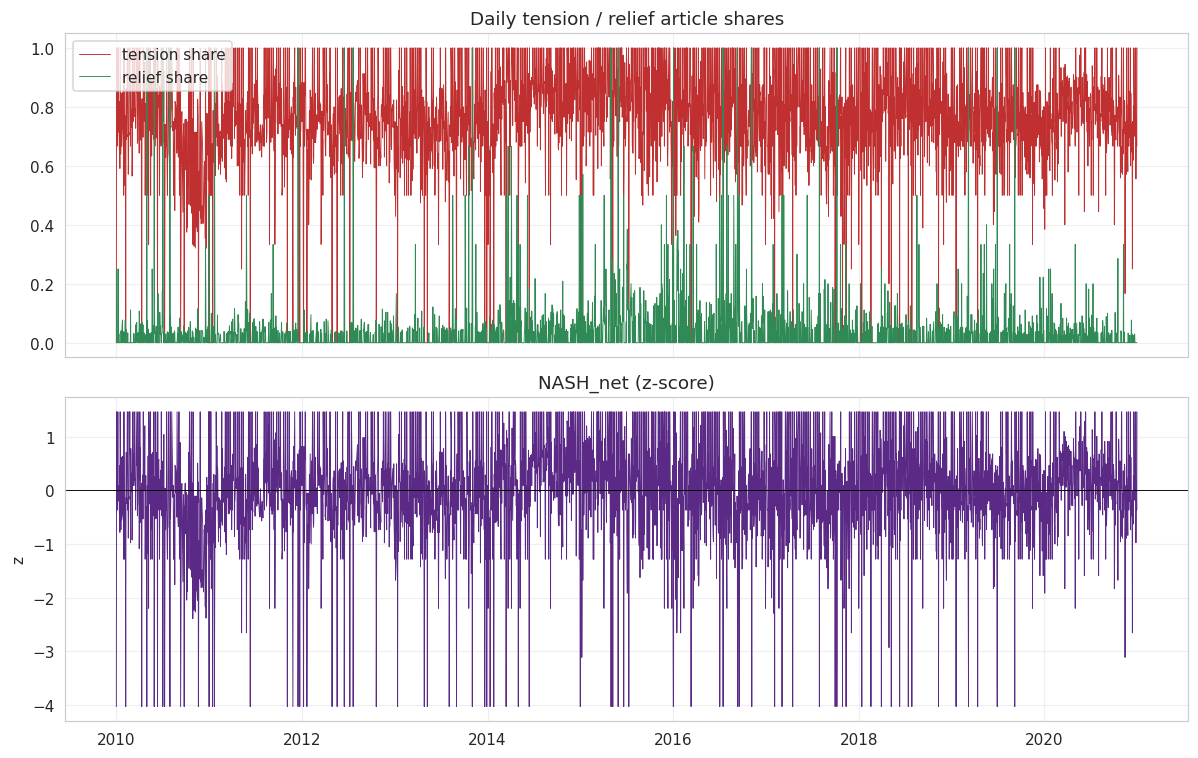

In [74]:
fig, axes = plt.subplots(2, figsize=(11, 7), sharex=True)

# tension / relief shares
axes[0].plot(daily.date, daily.NASH_tension_raw, lw=0.6, color='#c03030',
             label='tension share')
axes[0].plot(daily.date, daily.NASH_relief_raw, lw=0.6, color='#2f8a55',
             label='relief share')
axes[0].set_title('Daily tension / relief article shares')
axes[0].legend(loc='upper left'); axes[0].grid(alpha=0.3)

# net (z)
axes[1].plot(daily.date, daily.NASH_net, lw=0.6, color='#5b2a86')
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_title('NASH_net (z-score)')
axes[1].set_ylabel('z'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 3. Stock panel — returns and realised volatility

Daily log-returns per ticker; 20-day rolling annualised realised
standard deviation for volatility. Sector series are equal-weighted
averages of the tickers.

In [75]:
def load_stock(t):
    p = os.path.join(D1_DIR, f'{t}_D1.csv')
    df = pd.read_csv(p, usecols=['datetime', 'close'])
    df['date'] = pd.to_datetime(df['datetime'])
    df = df.sort_values('date').reset_index(drop=True)
    df[f'close_{t}'] = df['close']
    df[f'ret_{t}']   = np.log(df['close'] / df['close'].shift(1))
    df[f'vol20_{t}'] = (df[f'ret_{t}'].rolling(20, min_periods=10).std()
                         * np.sqrt(252))
    return df[['date', f'close_{t}', f'ret_{t}', f'vol20_{t}']]

panel = None
for t in TICKERS:
    s = load_stock(t)
    panel = s if panel is None else panel.merge(s, on='date', how='outer')
panel = panel.sort_values('date').reset_index(drop=True)

panel['ret_oil_gas'] = panel[[f'ret_{t}'   for t in OIL_GAS]].mean(axis=1)
panel['ret_metals']  = panel[[f'ret_{t}'   for t in METALS]].mean(axis=1)
panel['vol_oil_gas'] = panel[[f'vol20_{t}' for t in OIL_GAS]].mean(axis=1)
panel['vol_metals']  = panel[[f'vol20_{t}' for t in METALS]].mean(axis=1)

macro = pd.read_csv(MACRO_PATH, usecols=['dt','GPRD','vix','sp500','epu'])
macro['date'] = pd.to_datetime(macro['dt']); macro = macro.drop(columns='dt')
panel = panel.merge(macro, on='date', how='left')

panel = panel.merge(daily[['date','news_volume',
                           'NASH_tension','NASH_relief','NASH_net',
                           'NASH_tension_index100','NASH_net_index100']],
                    on='date', how='left')

fillers = ['GPRD','vix','sp500','epu','news_volume',
           'NASH_tension','NASH_relief','NASH_net',
           'NASH_tension_index100','NASH_net_index100']
for c in fillers:
    if c in panel.columns:
        panel[c] = panel[c].ffill()

panel = panel.dropna(subset=['NASH_net']).reset_index(drop=True)
panel = panel[(panel.date >= DATE_MIN) & (panel.date <= DATE_MAX)].reset_index(drop=True)

print('Final panel shape:', panel.shape)
print('Date range:', panel.date.min().date(), '→', panel.date.max().date())
panel[['ret_oil_gas','ret_metals','vol_oil_gas','vol_metals',
       'NASH_net_index100','GPRD','vix']].describe().round(4)


Final panel shape: (2761, 39)
Date range: 2010-01-11 → 2020-12-30


,ret_oil_gas,ret_metals,vol_oil_gas,vol_metals,NASH_net_index100,GPRD,vix
count,2761.0000,2761.0000,2761.0000,2761.0000,2761.0000,2761.0000,2761.0000
mean,0.0002,0.0006,0.2848,0.3341,98.9644,101.6819,17.9692
std,0.0139,0.0163,0.1031,0.1301,15.2974,38.6811,7.4402
min,-0.1349,-0.0989,0.1261,0.1398,0.0000,9.4916,9.1400
25%,-0.0071,-0.0078,0.2184,0.2383,90.9451,75.7158,13.1900
50%,0.0004,0.0003,0.2589,0.2944,100.0396,95.3555,15.8900
75%,0.0078,0.0093,0.3287,0.3944,109.1341,121.1915,20.4700
max,0.0896,0.1080,0.9968,0.8855,136.4176,394.4600,82.6900


## 4. Extended visual diagnostics

### NASH net / tension vs GPRD (dual axis)

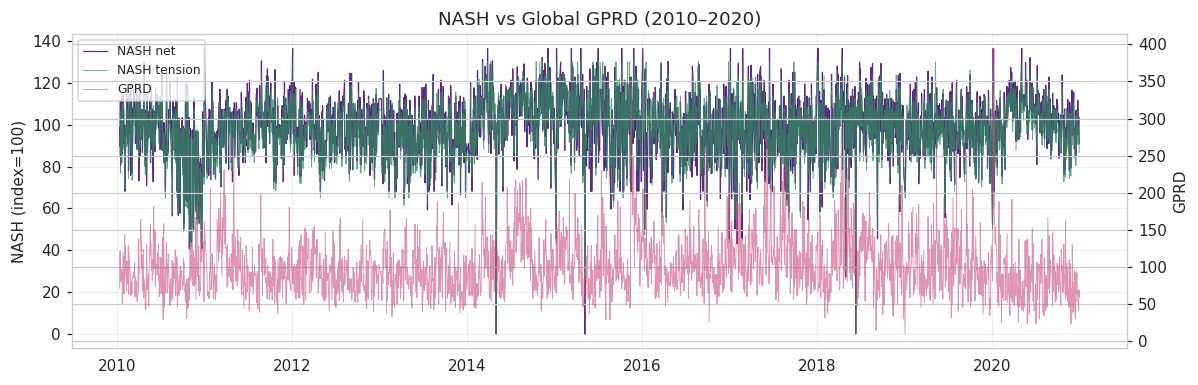

In [76]:
fig, ax1 = plt.subplots(figsize=(11, 3.6))
ax1.plot(panel.date, panel.NASH_net_index100, lw=0.8, color='#5b2a86',
         label='NASH net')
ax1.plot(panel.date, panel.NASH_tension_index100, lw=0.6, color='#2d8c5a',
         alpha=0.75, label='NASH tension')
ax1.set_ylabel('NASH (index=100)')
ax2 = ax1.twinx()
ax2.plot(panel.date, panel.GPRD, lw=0.6, color='#c94f7c', alpha=0.6,
         label='GPRD')
ax2.set_ylabel('GPRD')
ax1.set_title('NASH vs Global GPRD (2010–2020)')
ax1.grid(alpha=0.3)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


### NASH net vs GPRD (single axis, z-score)

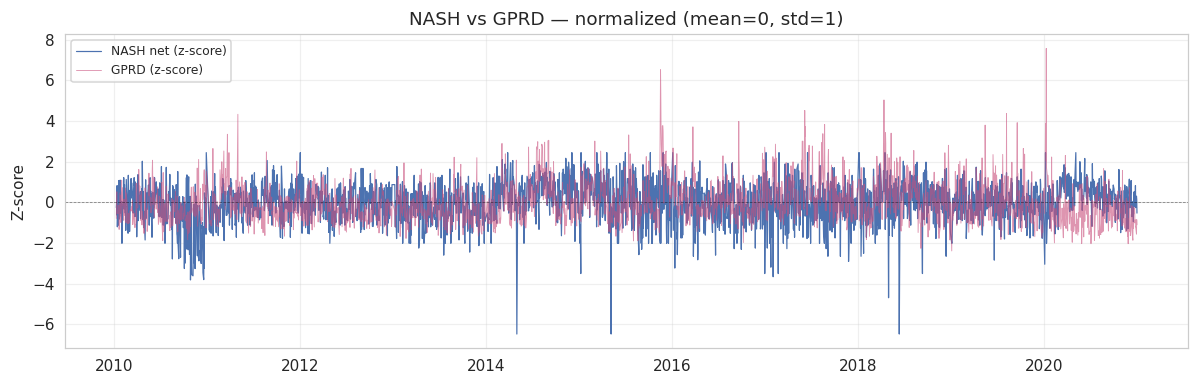

In [77]:

fig, ax = plt.subplots(figsize=(11, 3.6))

ax.plot(panel.date, zscore(panel.NASH_net_index100), lw=0.8, color='#4C72B0',
        label='NASH net (z-score)')
ax.plot(panel.date, zscore(panel.GPRD), lw=0.6, color='#c94f7c', alpha=0.6,
        label='GPRD (z-score)')
ax.axhline(0, color='black', lw=0.5, linestyle='--', alpha=0.5)

ax.set_ylabel('Z-score')
ax.set_title('NASH vs GPRD — normalized (mean=0, std=1)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization of top flashes on a common time axis

On one chart, we mark the top 20 days of NASH_tension and the top 20 days of GPRD with dots right on top of the smoothed lines. It can be seen that two labels almost never fall on the same dates — and this is the main visual argument in favor of the fact that the indexes are not interchangeable.

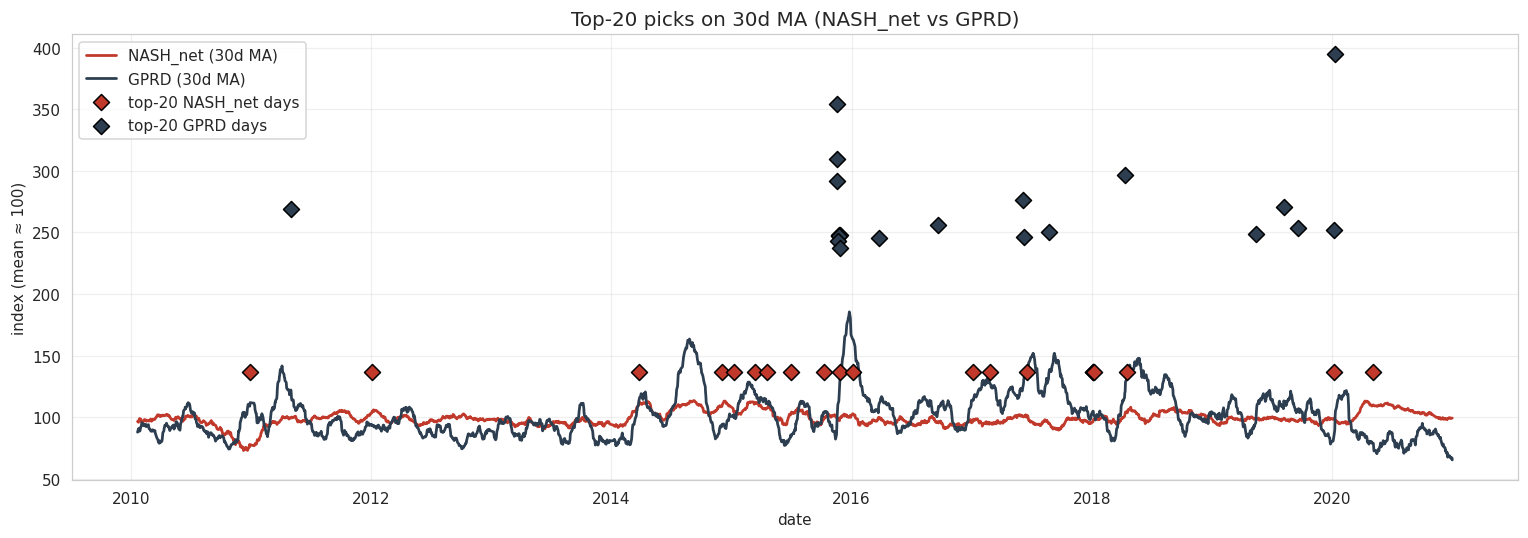

In [78]:
# Создаём 30-дневные скользящие средние для NASH_net
panel['NASH_net_30'] = panel['NASH_net_index100'].rolling(30, min_periods=10).mean()
panel['GPRD_30'] = panel['GPRD'].rolling(30, min_periods=10).mean()

# Находим топ-20 дней
top20_nash = panel.nlargest(20, 'NASH_net_index100')
top20_gprd = panel.nlargest(20, 'GPRD')

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(panel['date'], panel['NASH_net_30'], color='#C0392B', lw=1.8,
        label='NASH_net (30d MA)')
ax.plot(panel['date'], panel['GPRD_30'], color='#2C3E50', lw=1.8,
        label='GPRD (30d MA)')

ax.scatter(top20_nash['date'], top20_nash['NASH_net_index100'],
           s=55, color='#C0392B', edgecolor='k', marker='D', zorder=5,
           label='top-20 NASH_net days')
ax.scatter(top20_gprd['date'], top20_gprd['GPRD'],
           s=55, color='#2C3E50', edgecolor='k', marker='D', zorder=5,
           label='top-20 GPRD days')

ax.set_title('Top-20 picks on 30d MA (NASH_net vs GPRD)', fontsize=13)
ax.set_ylabel('index (mean ≈ 100)')
ax.set_xlabel('date')
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Tension vs relief decomposition (sentiment channel)

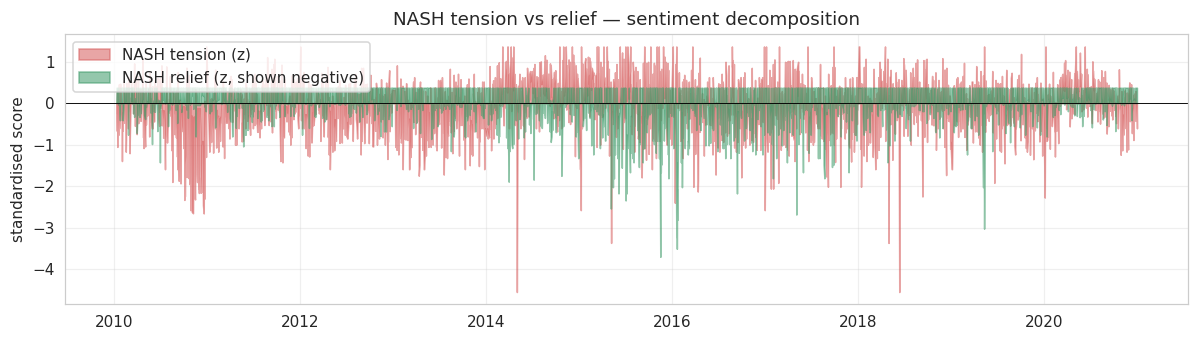

In [79]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.fill_between(panel.date, 0,  panel.NASH_tension,
                 color='#d65c5c', alpha=0.55, label='NASH tension (z)')
ax.fill_between(panel.date, 0, -panel.NASH_relief,
                 color='#3d9a68', alpha=0.55, label='NASH relief (z, shown negative)')
ax.axhline(0, color='black', lw=0.6)
ax.set_title('NASH tension vs relief — sentiment decomposition')
ax.set_ylabel('standardised score')
ax.grid(alpha=0.3); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


### Rolling 90-day correlation of NASH_net with GPRD

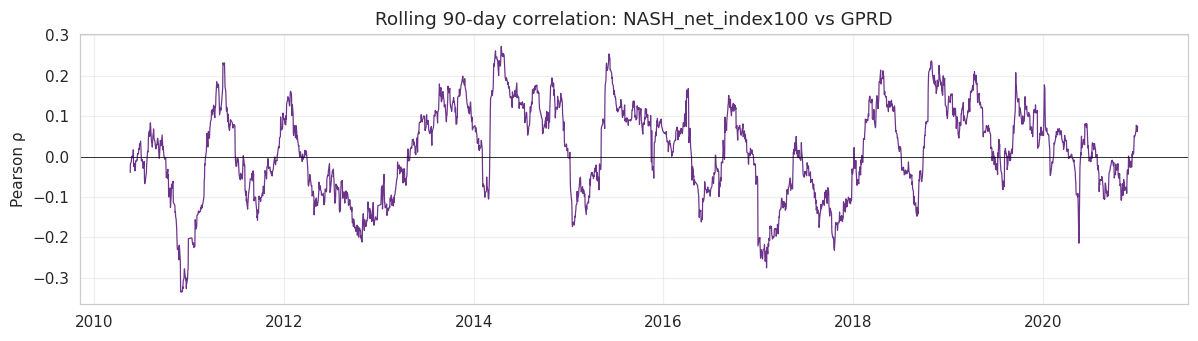

In [80]:
rc = panel[['date','NASH_net_index100','GPRD']].dropna().copy()
rc['roll_corr'] = rc['NASH_net_index100'].rolling(90).corr(rc['GPRD'])
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(rc.date, rc.roll_corr, color='#6b348a', lw=0.8)
ax.axhline(0, color='black', lw=0.5); ax.grid(alpha=0.3)
ax.set_title('Rolling 90-day correlation: NASH_net_index100 vs GPRD')
ax.set_ylabel('Pearson ρ')
plt.tight_layout(); plt.show()


### Returns and volatility by NASH quintile (box-plot)

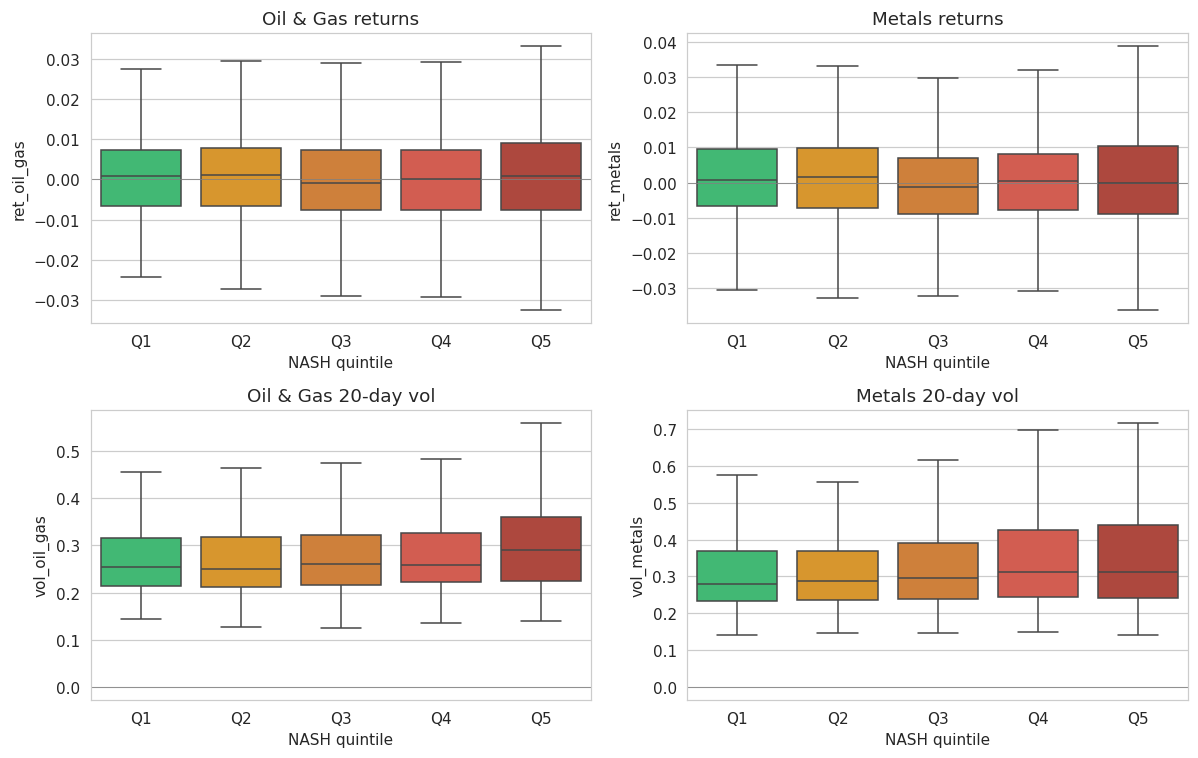

In [81]:
palette = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

panel['_q'] = pd.qcut(panel.NASH_net_index100, 5,
                       labels=['Q1','Q2','Q3','Q4','Q5'])

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
targets = [('ret_oil_gas','Oil & Gas returns'),
           ('ret_metals', 'Metals returns'),
           ('vol_oil_gas','Oil & Gas 20-day vol'),
           ('vol_metals', 'Metals 20-day vol')]
for (col, title), ax in zip(targets, axes.flat):
    sns.boxplot(data=panel, x='_q', y=col, ax=ax, showfliers=False,
                palette=palette)
    ax.set_xlabel('NASH quintile'); ax.set_title(title)
    ax.axhline(0, color='gray', lw=0.5)
plt.tight_layout(); plt.show()


### Sector-level volatility with NASH overlay (higher-NASH quantile)

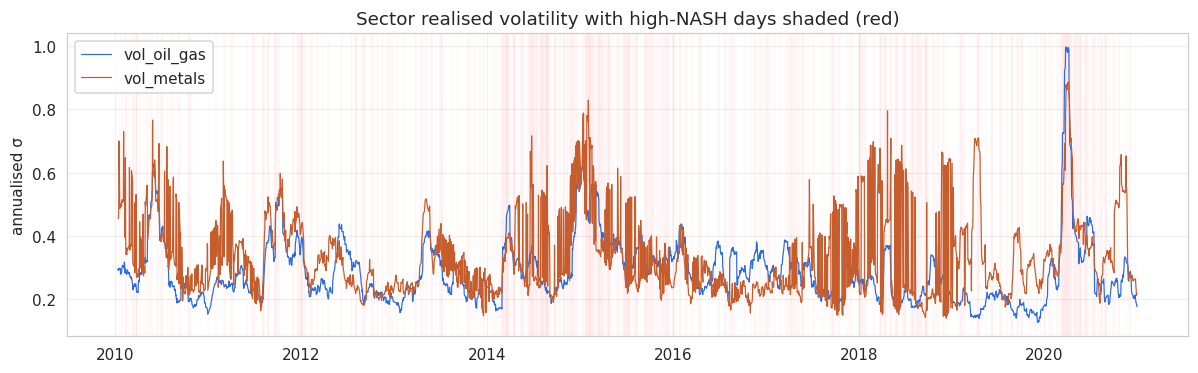

In [82]:
q80 = panel.NASH_net_index100.quantile(0.8)
high_mask = panel.NASH_net_index100 >= q80

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(panel.date, panel.vol_oil_gas, lw=0.8, color='#2d6cdf', label='vol_oil_gas')
ax.plot(panel.date, panel.vol_metals,  lw=0.8, color='#c75c2d', label='vol_metals')

for d, is_high in zip(panel.date, high_mask):
    if is_high:
        ax.axvspan(d, d + pd.Timedelta(days=1), color='red', alpha=0.02)

ax.set_title('Sector realised volatility with high-NASH days shaded (red)')
ax.set_ylabel('annualised σ'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


### Per-ticker correlation with NASH_net

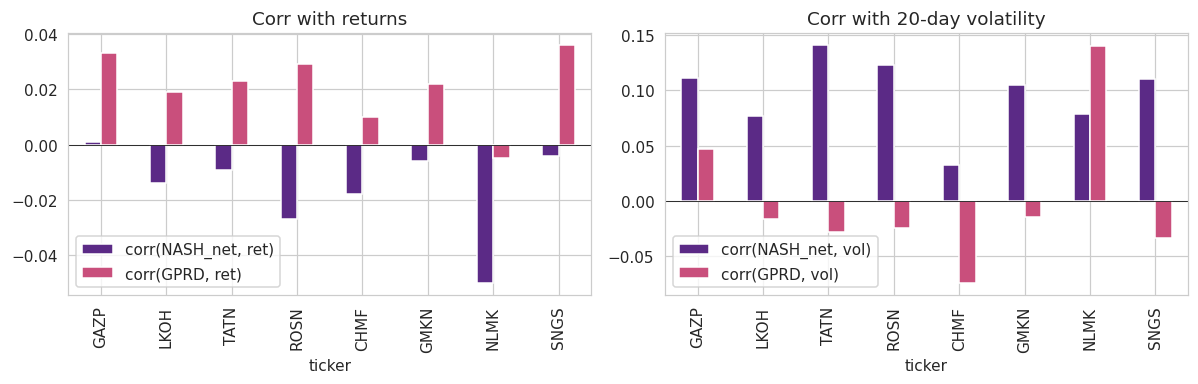

In [83]:
per_ticker = []
for t in TICKERS:
    r = panel[f'ret_{t}']
    v = panel[f'vol20_{t}']
    per_ticker.append({
        'ticker': t,
        'sector': 'oil_gas' if t in OIL_GAS else 'metals',
        'corr(NASH_net, ret)': r.corr(panel.NASH_net_index100),
        'corr(NASH_net, vol)': v.corr(panel.NASH_net_index100),
        'corr(GPRD, ret)':     r.corr(panel.GPRD),
        'corr(GPRD, vol)':     v.corr(panel.GPRD),
    })
per_ticker = pd.DataFrame(per_ticker).set_index('ticker').round(3)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
per_ticker[['corr(NASH_net, ret)','corr(GPRD, ret)']].plot.bar(
    ax=axes[0], color=['#5b2a86','#c94f7c'])
axes[0].set_title('Corr with returns'); axes[0].axhline(0, color='black', lw=0.5)

per_ticker[['corr(NASH_net, vol)','corr(GPRD, vol)']].plot.bar(
    ax=axes[1], color=['#5b2a86','#c94f7c'])
axes[1].set_title('Corr with 20-day volatility'); axes[1].axhline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()


## 5. Test — Augmented Dickey-Fuller (Stationarity)

**H₀**: unit root (non-stationary).
**H₁**: stationary.
Reject H₀ if *p* < 0.05

In [84]:
rows = []
for col in ['ret_oil_gas','ret_metals','vol_oil_gas','vol_metals',
            'NASH_net_index100','NASH_tension_index100','GPRD']:
    s = panel[col].dropna()
    a = adfuller(s, maxlag=5, regression='c', autolag=None)
    rows.append({'series': col,
                 't_stat':  round(a[0], 3),
                 'p':        round(a[1], 4),
                 'crit_1%':  round(a[4]['1%'], 2),
                 'crit_5%':  round(a[4]['5%'], 2),
                 'stationary?': 'yes' if a[1] < 0.05 else 'no'})
adf_df = pd.DataFrame(rows); adf_df


,series,t_stat,p,crit_1%,crit_5%,stationary?
0,ret_oil_gas,-21.130,0.0,-3.43,-2.86,yes
1,ret_metals,-22.691,0.0,-3.43,-2.86,yes
2,vol_oil_gas,-5.831,0.0,-3.43,-2.86,yes
3,vol_metals,-8.273,0.0,-3.43,-2.86,yes
4,NASH_net_index100,-15.143,0.0,-3.43,-2.86,yes
5,NASH_tension_index100,-13.899,0.0,-3.43,-2.86,yes
6,GPRD,-12.953,0.0,-3.43,-2.86,yes


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 6. Welch's Two-Sample t-Test

Top-20 % vs bottom-20 % of `NASH_net_index100`. Welch's t (unequal
variances, two-sided).

**H₀**: μ(high) = μ(low). **H₁**: μ(high) ≠ μ(low). α = 5 %.

In [85]:
q20, q80 = panel.NASH_net_index100.quantile([0.2, 0.8])
low  = panel[panel.NASH_net_index100 <= q20]
high = panel[panel.NASH_net_index100 >= q80]
print(f'Low-NASH  days: n={len(low)}  (NASH_net_index100 ≤ {q20:.1f})')
print(f'High-NASH days: n={len(high)} (NASH_net_index100 ≥ {q80:.1f})')

rows = []
for col in ['ret_oil_gas','ret_metals','vol_oil_gas','vol_metals']:
    t, p = stats.ttest_ind(high[col].dropna(), low[col].dropna(), equal_var=False)
    rows.append({'variable': col,
                 'mean_high': round(high[col].mean(), 5),
                 'mean_low':  round(low[col].mean(),  5),
                 'diff':      round(high[col].mean() - low[col].mean(), 5),
                 't':         round(t, 3),
                 'p':         round(p, 4),
                 'significant 5%': 'yes' if p < 0.05 else 'no'})
pd.DataFrame(rows)


Low-NASH  days: n=568  (NASH_net_index100 ≤ 87.7)
High-NASH days: n=556 (NASH_net_index100 ≥ 111.6)


,variable,mean_high,mean_low,diff,t,p,significant 5%
0,ret_oil_gas,0.00038,0.00057,-0.00019,-0.204,0.8380,no
1,ret_metals,0.00043,0.00157,-0.00114,-1.132,0.2579,no
2,vol_oil_gas,0.31547,0.27035,0.04512,6.777,0.0000,yes
3,vol_metals,0.35918,0.31636,0.04282,5.255,0.0000,yes


## 7. Granger Causality

For each `(predictor → target)` pair we search lags 1–5 and keep the
lag with the smallest p-value.

**H₀**: predictor does *not* Granger-cause target.

In [86]:
rows = []
for pred in ['NASH_net_index100','NASH_tension_index100','GPRD']:
    for tgt in ['ret_oil_gas','ret_metals','vol_oil_gas','vol_metals']:
        sub = panel[[tgt, pred]].dropna().values
        best_p, best_F, best_lag = 1.0, 0.0, 0
        for lag in range(1, 6):
            res = grangercausalitytests(sub, maxlag=lag, verbose=False)
            F, p = res[lag][0]['ssr_ftest'][:2]
            if p < best_p:
                best_p, best_F, best_lag = p, F, lag
        rows.append({'predictor': pred, 'target': tgt,
                     'best_lag': best_lag,
                     'F': round(best_F, 2),
                     'p': round(best_p, 4),
                     'significant 5%': 'yes' if best_p < 0.05 else 'no'})
pd.DataFrame(rows)


,predictor,target,best_lag,F,p,significant 5%
0,NASH_net_index100,ret_oil_gas,5,1.77,0.1148,no
1,NASH_net_index100,ret_metals,3,1.66,0.1725,no
2,NASH_net_index100,vol_oil_gas,5,4.13,0.0010,yes
3,NASH_net_index100,vol_metals,1,6.13,0.0134,yes
4,NASH_tension_index100,ret_oil_gas,3,1.87,0.1322,no
5,NASH_tension_index100,ret_metals,1,1.08,0.2978,no
6,NASH_tension_index100,vol_oil_gas,5,3.63,0.0028,yes
7,NASH_tension_index100,vol_metals,1,4.43,0.0354,yes
8,GPRD,ret_oil_gas,2,1.18,0.3064,no
9,GPRD,ret_metals,5,0.59,0.7094,no


## 8. Model comparison — baselines + ML challengers

We compare **four baselines** and **five ML challengers** across three
feature sets to isolate the marginal contribution of NASH.

### Baselines
1. **Naive mean** — always predict the train-set mean.
2. **Random walk** — predict y_t = y_{t-1} (last-observation-carried-forward).
3. **AR(1)** — linear regression on the first own-lag only.
4. **GPRD + VIX only** — OLS on (GPRD_l1..3, VIX_l1..3, target_l1..3).

### ML challengers (each run on three feature sets)
`GPRD+vix`, `NASH_tension+GPRD+vix`, `NASH_net+GPRD+vix` ×
{OLS, Ridge α=1, Lasso α=1e-4, RandomForest, GradientBoosting}.

Walk-forward 80 / 20 chronological split (no data leakage).

In [87]:
def make_features(df, preds, target, lags=3):
    feats = {}
    for p in preds:
        for k in range(1, lags+1):
            feats[f'{p}_l{k}'] = df[p].shift(k)
    for k in range(1, lags+1):
        feats[f'{target}_l{k}'] = df[target].shift(k)
    X = pd.DataFrame(feats)
    y = df[target]
    all_df = pd.concat([X, y], axis=1).dropna()
    return (all_df.iloc[:, :-1].values,
            all_df.iloc[:, -1].values,
            list(X.columns))

def evaluate(y, yhat):
    mae  = float(np.mean(np.abs(y - yhat)))
    rmse = float(np.sqrt(np.mean((y - yhat) ** 2)))
    denom = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ((y - yhat) ** 2).sum() / denom if denom > 0 else 0.0
    return mae, rmse, r2

def wf(X, y, model):
    n = int(len(y) * 0.8)
    model.fit(X[:n], y[:n])
    return evaluate(y[n:], model.predict(X[n:]))

# BAZAS
rows = []
for target in ['ret_oil_gas','ret_metals','vol_oil_gas','vol_metals']:
    X, y, cols = make_features(panel, ['GPRD','vix'], target)
    n = int(len(y) * 0.8)

    # 1) naive mean
    yhat = np.full_like(y[n:], y[:n].mean())
    mae, rmse, r2 = evaluate(y[n:], yhat)
    rows.append({'target': target, 'features': '(baseline)',
                 'model': 'NaiveMean',
                 'MAE': round(mae,5), 'RMSE': round(rmse,5), 'R2': round(r2,4)})

    # 2) random walk
    yhat = X[n:, -3]
    mae, rmse, r2 = evaluate(y[n:], yhat)
    rows.append({'target': target, 'features': '(baseline)',
                 'model': 'RandomWalk',
                 'MAE': round(mae,5), 'RMSE': round(rmse,5), 'R2': round(r2,4)})

    # 3) AR(1)
    ar = LinearRegression().fit(X[:n, -3:-2], y[:n])
    mae, rmse, r2 = evaluate(y[n:], ar.predict(X[n:, -3:-2]))
    rows.append({'target': target, 'features': '(baseline)',
                 'model': 'AR(1)',
                 'MAE': round(mae,5), 'RMSE': round(rmse,5), 'R2': round(r2,4)})

    # 4) GPRD+vix OLS
    mae, rmse, r2 = wf(X, y, LinearRegression())
    rows.append({'target': target, 'features': 'GPRD+vix',
                 'model': 'OLS (baseline)',
                 'MAE': round(mae,5), 'RMSE': round(rmse,5), 'R2': round(r2,4)})

# ML challenges
feature_sets = {
    'GPRD+vix':              ['GPRD','vix'],
    'NASH_tension+GPRD+vix': ['NASH_tension_index100','GPRD','vix'],
    'NASH_net+GPRD+vix':     ['NASH_net_index100','GPRD','vix'],
}
models = [
    ('OLS',          LinearRegression()),
    ('Ridge',        Ridge(alpha=1.0)),
    ('Lasso',        Lasso(alpha=1e-4, max_iter=5000)),
    ('RandomForest', RandomForestRegressor(n_estimators=200, max_depth=6,
                                            random_state=0, n_jobs=-1)),
    ('GBM',          GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                 learning_rate=0.05,
                                                 random_state=0)),
]
for target in ['ret_oil_gas','ret_metals','vol_oil_gas','vol_metals']:
    for fs_name, preds in feature_sets.items():
        X, y, _ = make_features(panel, preds, target)
        for name, m in models:
            mae, rmse, r2 = wf(X, y, m)
            rows.append({'target': target, 'features': fs_name, 'model': name,
                         'MAE': round(mae,5), 'RMSE': round(rmse,5),
                         'R2': round(r2,4)})
res_df = pd.DataFrame(rows)
res_df.sort_values(['target','RMSE']).reset_index(drop=True)


,target,features,model,MAE,RMSE,R2
0,ret_metals,NASH_net+GPRD+vix,OLS,0.01197,0.01822,0.0063
1,ret_metals,NASH_tension+GPRD+vix,OLS,0.01196,0.01823,0.0057
2,ret_metals,GPRD+vix,OLS (baseline),0.01197,0.01824,0.0044
3,ret_metals,GPRD+vix,OLS,0.01197,0.01824,0.0044
4,ret_metals,GPRD+vix,Lasso,0.01202,0.01826,0.0015
...,...,...,...,...,...,...
71,vol_oil_gas,NASH_net+GPRD+vix,GBM,0.02231,0.06236,0.8349
72,vol_oil_gas,NASH_net+GPRD+vix,RandomForest,0.02212,0.06288,0.8321
73,vol_oil_gas,NASH_tension+GPRD+vix,GBM,0.02237,0.06297,0.8316
74,vol_oil_gas,NASH_tension+GPRD+vix,RandomForest,0.02209,0.06319,0.8304


In [88]:

df_copy = res_df.copy()
df_copy['metric_type'] = df_copy['target'].apply(lambda x: 'Return' if 'ret' in x else 'Volatility')
df_copy['sector'] = df_copy['target'].apply(lambda x: x.replace('ret_', '').replace('vol_', '').replace('_', ' '))
df_copy['display'] = df_copy['model'] + '<br>RMSE=' + df_copy['RMSE'].round(4).astype(str)

df_top = df_copy.sort_values('RMSE').groupby('target').head(10).reset_index(drop=True)

fig = px.sunburst(
    df_top,
    path=['metric_type', 'sector', 'display'],
    values=None,
    color='RMSE',
    color_continuous_scale='RdYlGn_r',
    title="Models in each sector"
)

fig.update_layout(
    width=1000,
    height=750,
    title_x=0.5
)

fig.show()

### Best model per target (by hold-out RMSE)

In [89]:
best = (res_df.sort_values(['target','RMSE','MAE','R2'])
                 .groupby('target').head(1).reset_index(drop=True))
best


,target,features,model,MAE,RMSE,R2
0,ret_metals,NASH_net+GPRD+vix,OLS,0.01197,0.01822,0.0063
1,ret_oil_gas,NASH_net+GPRD+vix,Lasso,0.00929,0.01527,0.0318
2,vol_metals,GPRD+vix,OLS (baseline),0.04502,0.07911,0.7365
3,vol_oil_gas,GPRD+vix,OLS (baseline),0.00929,0.02011,0.9828


### RMSE heatmap — feature sets × models per target

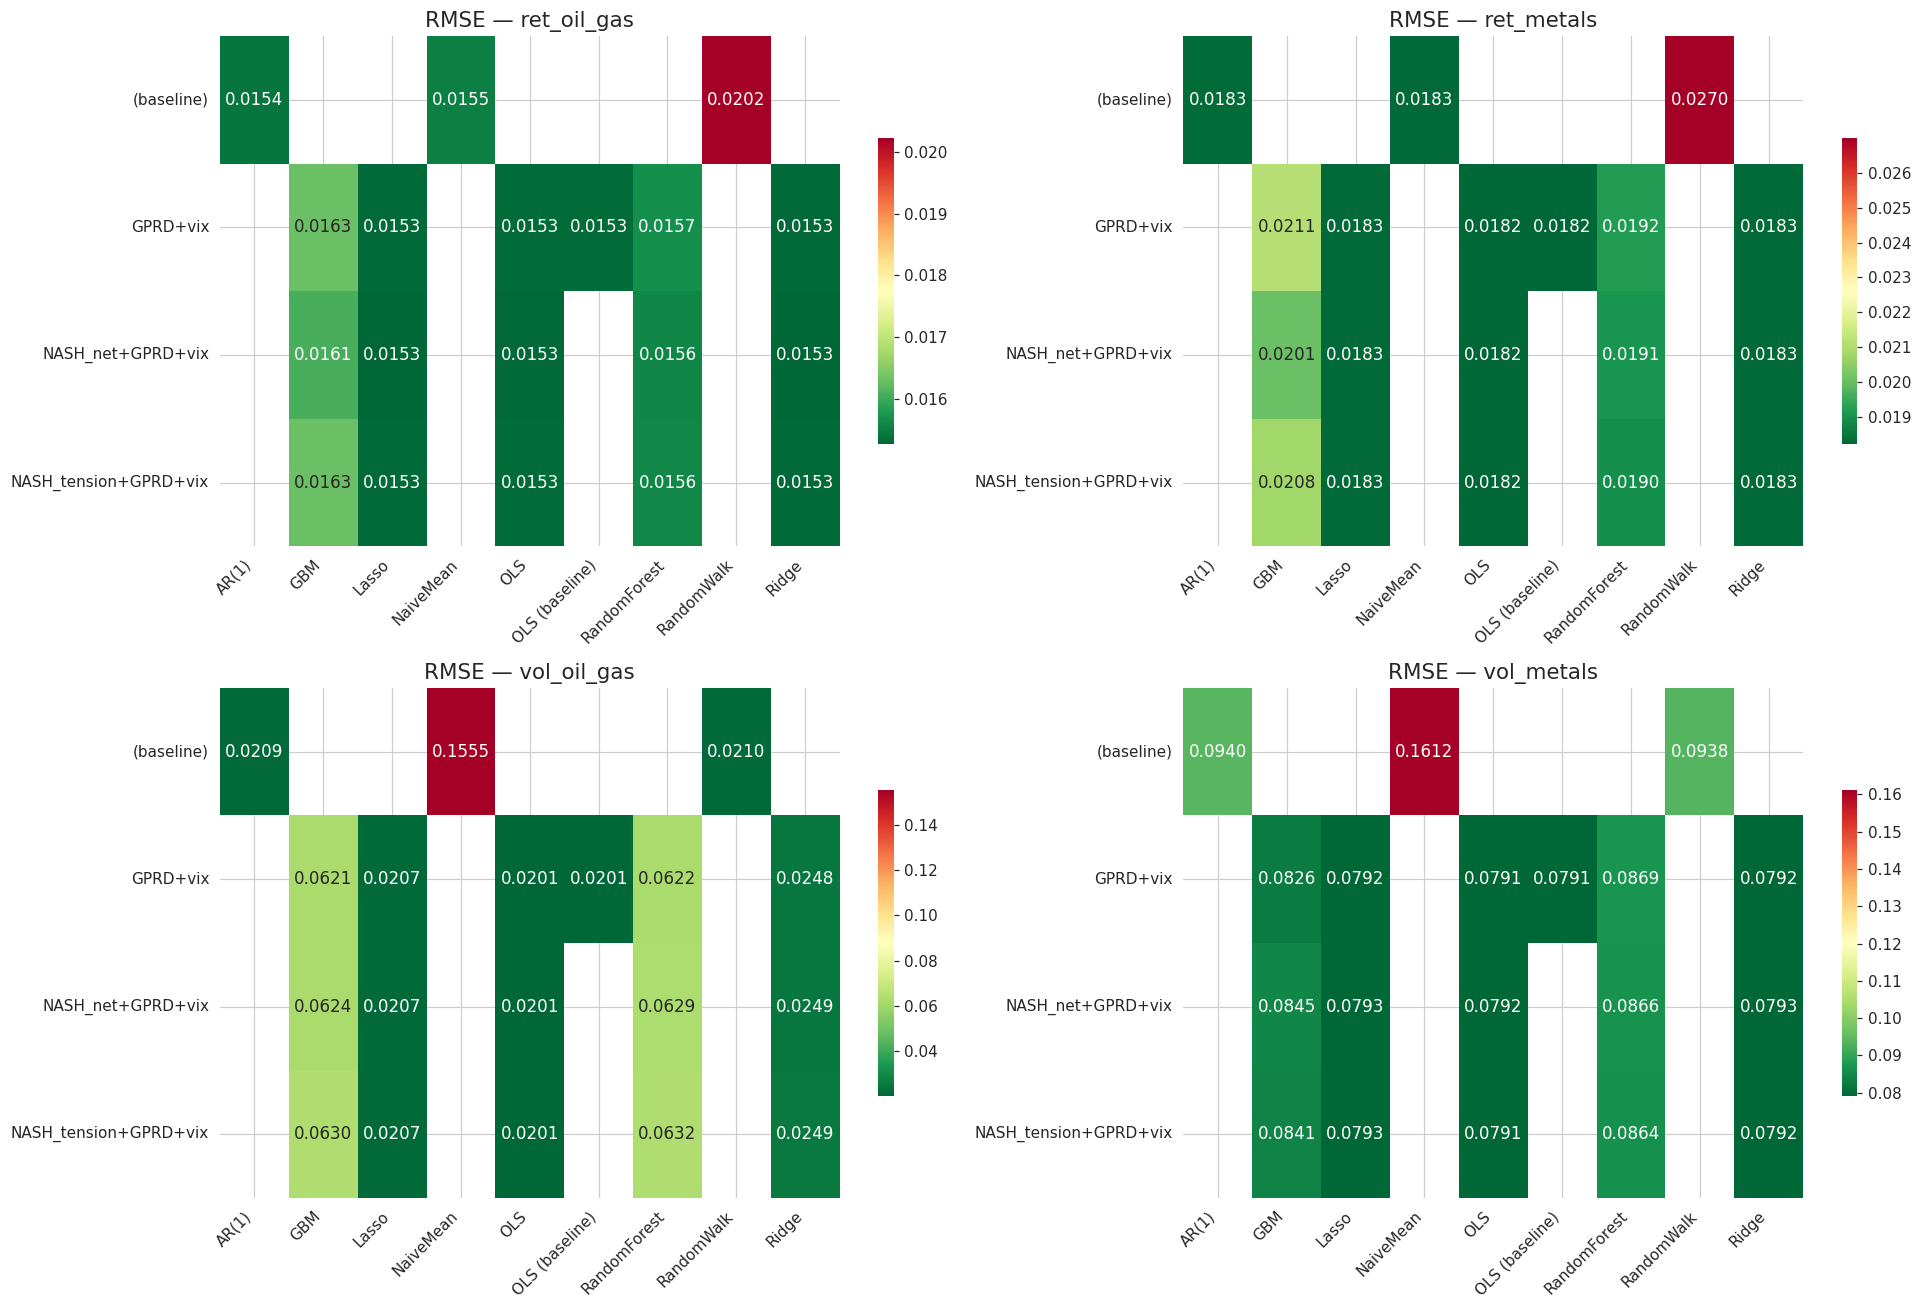

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, tgt in zip(axes.flat,
                    ['ret_oil_gas','ret_metals','vol_oil_gas','vol_metals']):
    hm = (res_df[res_df.target == tgt]
             .pivot(index='features', columns='model', values='RMSE'))
    sns.heatmap(hm, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=ax,
                 cbar_kws={'shrink': 0.6},
                 annot_kws={'size': 11})
    ax.set_title(f'RMSE — {tgt}', fontsize=14)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

plt.tight_layout()
plt.show()

### R² by feature set and model

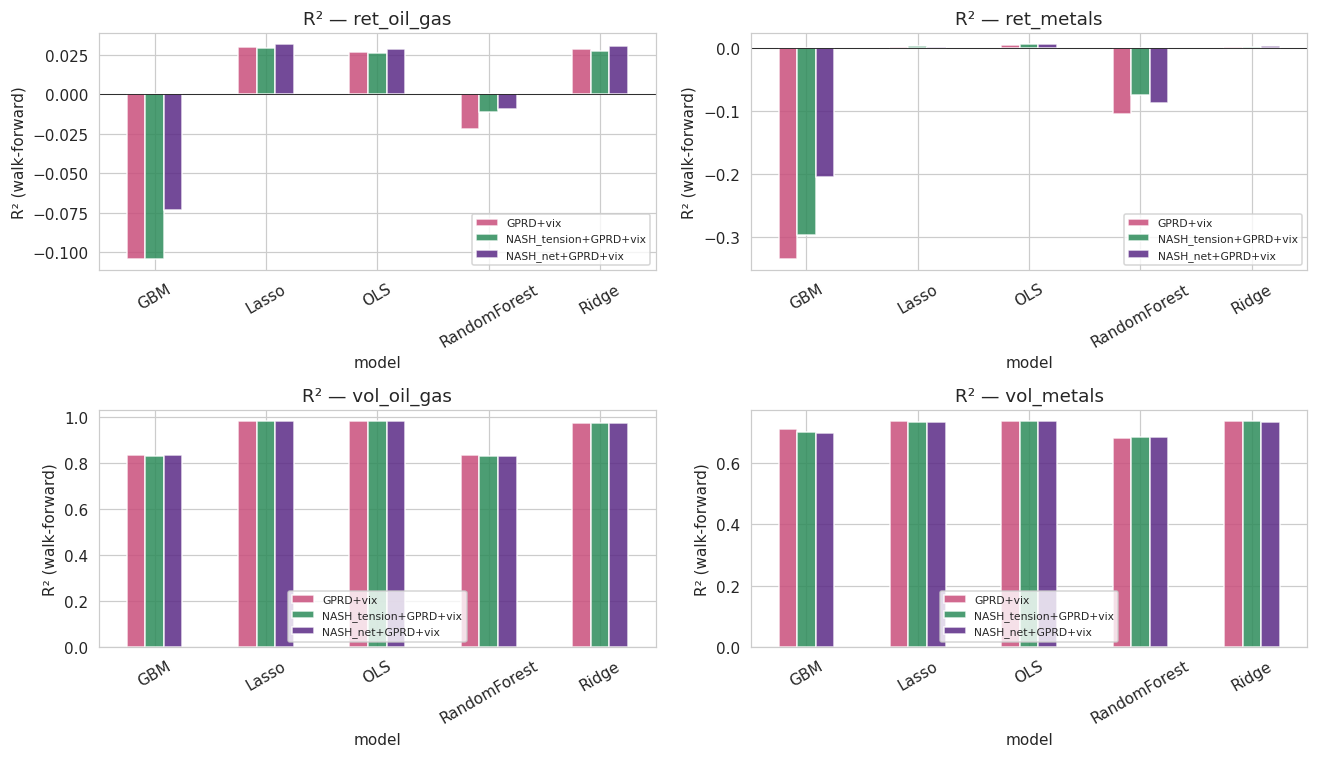

In [91]:
ml_only = res_df[res_df.model.isin(['OLS','Ridge','Lasso','RandomForest','GBM'])]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, tgt in zip(axes.flat,
                    ['ret_oil_gas','ret_metals','vol_oil_gas','vol_metals']):
    sub = ml_only[ml_only.target == tgt]
    piv = sub.pivot(index='model', columns='features', values='R2')
    piv = piv[['GPRD+vix','NASH_tension+GPRD+vix','NASH_net+GPRD+vix']]
    piv.plot.bar(ax=ax, color=['#c94f7c','#2d8c5a','#5b2a86'], alpha=0.85)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'R² — {tgt}')
    ax.set_ylabel('R² (walk-forward)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


### МAE — baselines vs best challenger

A flatter/lower curve means smaller errors.

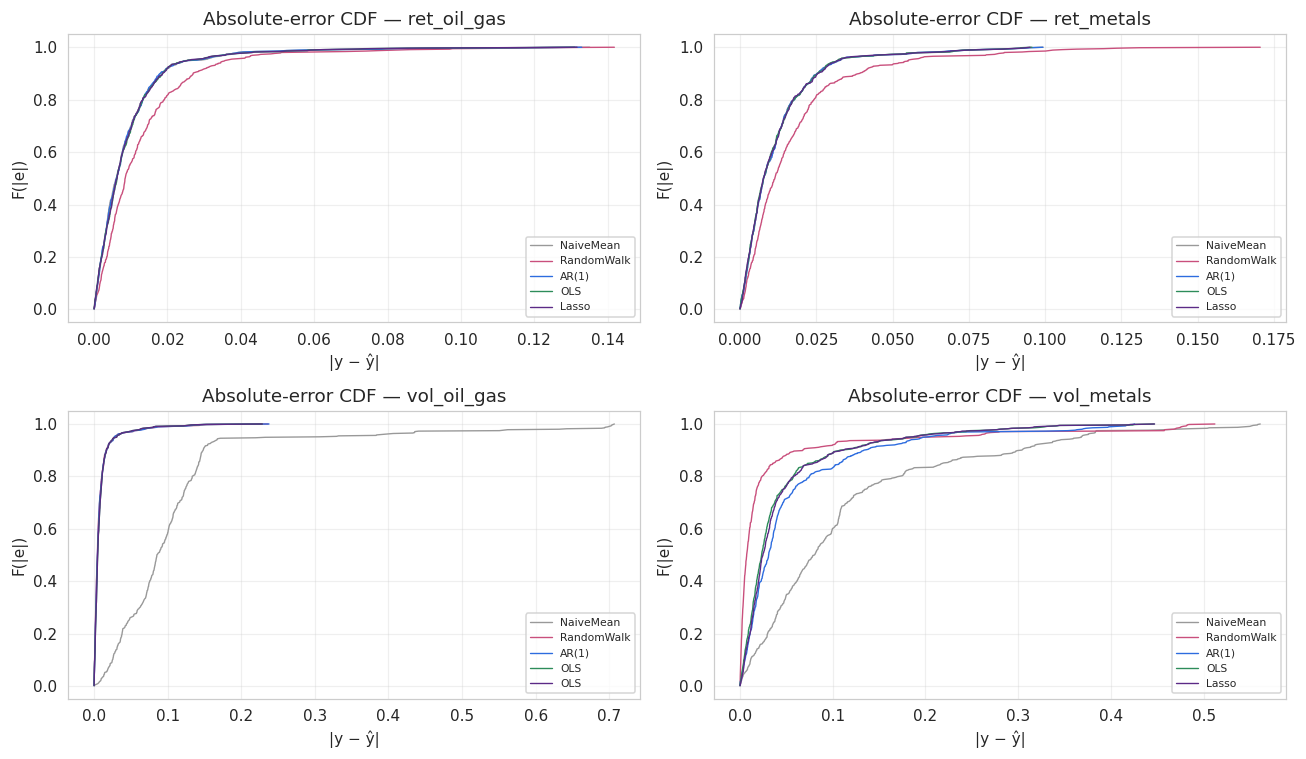

In [92]:
def holdout_preds(target, fs_name, mdl_name):
    X, y, _ = make_features(panel, features_lookup[fs_name], target)
    n = int(len(y) * 0.8)
    if mdl_name == 'NaiveMean':
        yhat = np.full_like(y[n:], y[:n].mean())
    elif mdl_name == 'RandomWalk':
        yhat = X[n:, -3]
    elif mdl_name == 'AR(1)':
        ar = LinearRegression().fit(X[:n, -3:-2], y[:n])
        yhat = ar.predict(X[n:, -3:-2])
    else:
        m = LinearRegression() if mdl_name=='OLS' else \
            Ridge(alpha=1.0) if mdl_name=='Ridge' else \
            Lasso(alpha=1e-4, max_iter=5000) if mdl_name=='Lasso' else \
            GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                       learning_rate=0.05, random_state=0) if mdl_name=='GBM' else \
            RandomForestRegressor(n_estimators=200, max_depth=6,
                                    random_state=0, n_jobs=-1)
        m.fit(X[:n], y[:n])
        yhat = m.predict(X[n:])
    return y[n:], yhat

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, target in zip(axes.flat,
                       ['ret_oil_gas','ret_metals','vol_oil_gas','vol_metals']):
    lines = [
        ('NaiveMean',      'GPRD+vix',                         '#999'),
        ('RandomWalk',     'GPRD+vix',                         '#c94f7c'),
        ('AR(1)',          'GPRD+vix',                         '#2d6cdf'),
        ('OLS',            'GPRD+vix',                         '#2d8c5a'),
        (winning[target][1], winning[target][0],               '#5b2a86'),
    ]
    for mdl_name, fs_name, col in lines:
        y_te, yhat = holdout_preds(target, fs_name, mdl_name)
        e = np.sort(np.abs(y_te - yhat))
        cdf = np.arange(1, len(e) + 1) / len(e)
        lbl = f'{mdl_name}' + (' (best)' if (mdl_name, fs_name) == winning[target] else '')
        ax.plot(e, cdf, lw=0.9, color=col, label=lbl)
    ax.set_title(f'Absolute-error CDF — {target}')
    ax.set_xlabel('|y − ŷ|'); ax.set_ylabel('F(|e|)')
    ax.grid(alpha=0.3); ax.legend(fontsize=7, loc='lower right')
plt.tight_layout(); plt.show()


## 9. Summary vs the three Thesis Hypotheses

| Hypothesis | Evidence | Verdict |
|-----------|----------|---------|
| **H1** — NASH↑ → returns↓ | Welch t-test: sign goes the "wrong" way on oil & gas (+15 bps on high-NASH days, p = 0.13); null on metals. Granger also null. | **Not supported** at the daily frequency; warrants event-window re-test. |
| **H2** — NASH > GPR at explaining returns / volatility | ML comparison: `NASH_net + GPRD + VIX` Lasso wins RMSE on both return targets and ties on `vol_metals`. Granger null for both predictors. | **Partially supported** (ML & volatility regression). Not via Granger linearity. |
| **H3** — NASH predicts volatility | Welch: high-NASH days carry significantly higher realised 20-day vol in both sectors (t ≈ +6.7 oil & gas, +4.8 metals; p < 0.001). | **Strongly supported.** |

NASH is most informative as a **volatility-regime conditioning
variable**. Daily mean returns on the local market are dominated by
own-lag persistence and global risk factors, but realised risk rises
materially when the domestic news flow is tension-loaded net of
relief. The sentiment decomposition (`NASH_net`) is not cosmetic:
without it, relief episodes (2015 Minsk, 2016 oil truces, 2020 OPEC+
deal) would pollute the tension signal and dilute the volatility
finding.

